# Predicting Emotions Using LLMs on IEMOCAP Data

### Install

In [1]:
%pip install "pandas<3.0.0" "python-dotenv" "openai" "google-genai" "anthropic" "scikit-learn" "seaborn" -U -q

Note: you may need to restart the kernel to use updated packages.


### Load API Keys

In [2]:
from dotenv import load_dotenv
import os

# loading variables from .env
load_dotenv() 

True

#### Gemini

In [3]:
from google import genai

client_gemini = genai.Client(
    api_key=os.getenv('GEMINI_API_KEY')
)

#### OpenAI

In [4]:
from openai import OpenAI

# Looks for an environment variable named OPENAI_API_KEY
client_openai = OpenAI()

#### Anthropic

In [5]:
import anthropic

client_claude = anthropic.Anthropic(
    api_key=os.getenv("ANTHROPIC_API_KEY")
)

### Predict Emotions

In [9]:
import json
import re

def predict_dialogue_emotions(client, dialogue_group, model="gpt"):
    """Sends an entire dialogue to Gemini 2.5 and gets a list of emotions back."""
    valid_labels = ["angry", "happy", "sad", "neutral"]
    
    # Format the dialogue turns for the prompt
    turns = [f"Turn {i+1}: {r['utterance']}" for i, r in enumerate(dialogue_group)]
    dialogue_text = "\n".join(turns)

    prompt = f"""Task: Assign exactly one emotion label to EACH turn in the dialogue below.
    Return a JSON object with the key "predictions" containing a list of strings.
    The length of the list must be exactly {len(dialogue_group)}.

    DIALOGUE TO ANALYZE:
    {dialogue_text}

    ALLOWED LABELS: {valid_labels}

    Output Format: {{"predictions": ["Label1", "Label2", ...]}}"""
    
    try:
        if model == "gemini":
            response = client.models.generate_content(
                model="gemini-2.5-flash",
                contents=prompt,
                config={'response_mime_type': 'application/json'}
            )
            raw_content = response.text
        elif model == "gpt":
            response = client.chat.completions.create(
                model="gpt-4o-mini",
                messages=[{"role": "user", "content": prompt}],
                response_format={"type": "json_object"},
                temperature=0.0,
                # max_tokens=500
            )
            raw_content = response.choices[0].message.content
        elif model == "claude":
            response = client_claude.messages.create(
                model="claude-sonnet-4-6", 
                max_tokens=2048,
                messages=[
                    {"role": "user", "content": prompt}
                ]
            )
            raw_content = response.content[0].text.strip()
            json_match = re.search(r'\{.*\}', raw_content, re.DOTALL)
            if json_match:
                raw_content = json_match.group(0)
        else:
            raise ValueError(f"Unsupported model: {model}")
        data = json.loads(raw_content)
        
        if isinstance(data, dict) and "predictions" in data:
            predictions = data["predictions"]
        elif isinstance(data, dict) and "emotions" in data: 
            predictions = data["emotions"]
        else:
            predictions = data

        if not isinstance(predictions, list) or len(predictions) != len(dialogue_group):
            return ["neutral"] * len(dialogue_group)
            
        return [p if p in valid_labels else "neutral" for p in predictions]
    except Exception as e:
        print(f"Error: {e}")
        return ["neutral"] * len(dialogue_group)

### Load IEMOCAP Data and Predict Emotions

In [10]:
import pandas as pd
from tqdm.auto import tqdm

def process_iemocap_batch(client, file_path, output_csv="results.csv", model="openai"):
    df = pd.read_csv(file_path)

    processed_ids = set()
    if os.path.exists(output_csv):
        existing_df = pd.read_csv(output_csv)
        if not existing_df.empty:
            processed_ids = set(existing_df['id'].unique())
            print(f"Skipping {len(processed_ids)} already processed dialogues.")
    
    results = []
    grouped = df.groupby('file_id')

    for diag_id, group in tqdm(grouped, desc="Processing Dialogues"):
        if diag_id in processed_ids:
            continue
        group_list = group.to_dict('records')
        try:
            predictions = predict_dialogue_emotions(client, group_list, model)
            
            curr_batch = []
            for i, row in enumerate(group_list):
                curr_batch.append({
                    'Dialogue_ID': diag_id,
                    'Utterance_ID': row['id'],
                    'Original_Emotion': row['label'],
                    'Predicted_Emotion': predictions[i] if i < len(predictions) else "neutral"
                })
            
            new_df = pd.DataFrame(curr_batch)
            if not os.path.isfile(output_csv):
                new_df.to_csv(output_csv, index=False)
            else:
                new_df.to_csv(output_csv, mode='a', header=False, index=False)
            results.extend(curr_batch)
        except Exception as e:
            if "429" in str(e):
                print("\nQuota hit! Saving and exiting...")
                pd.DataFrame(results).to_csv(output_csv, index=False)
                return  # Exit gracefully so you can restart later
            print(f"Error at {diag_id}: {e}")

    return pd.DataFrame(results)

#### Predict Using Gemini 2.5 Flash

In [ ]:
results_gemini = process_iemocap_batch(client_gemini, r"../../../data/iemocap_4way_data/train_unified_filtered.csv", "../../../results/4way/iemocap_llm/results_gemini.csv", "gemini")

Processing Dialogues:  10%|█         | 7/68 [01:50<15:47, 15.53s/it]

Error: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}


Processing Dialogues:  12%|█▏        | 8/68 [01:52<11:05, 11.10s/it]

Error: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}


Processing Dialogues:  28%|██▊       | 19/68 [05:42<10:10, 12.47s/it]

...

Error: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 55.10722775s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTier', 'quotaDimensions': {'location': 'global', 'model': 'gemini-2.5-flash'}, 'quota

Processing Dialogues:  97%|█████████▋| 66/68 [08:08<00:00,  6.60it/s]

Error: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 54.798404579s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTier', 'quotaDimensions': {'model': 'gemini-2.5-flash', 'location': 'global'}, 'quot

Processing Dialogues: 100%|██████████| 68/68 [08:09<00:00,  7.19s/it]

Error: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 54.498680038s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTier', 'quotaDimensions': {'location': 'global', 'model': 'gemini-2.5-flash'}, 'quot

#### Predict Using GPT 4o Mini

In [ ]:
results_openai = process_iemocap_batch(client_openai, r"../../../data/iemocap_4way_data/train_unified_filtered.csv", "../../../results/4way/iemocap_llm/results_openai.csv", "gpt")

Processing Dialogues:   1%|▏         | 1/68 [00:02<03:01,  2.72s/it]

Error: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}


Processing Dialogues:   3%|▎         | 2/68 [00:04<02:24,  2.18s/it]

Error: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}


Processing Dialogues:   4%|▍         | 3/68 [00:06<02:04,  1.91s/it]

...

Error: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}


Processing Dialogues:  10%|█         | 7/68 [00:12<01:38,  1.61s/it]

Error: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}


Processing Dialogues:  10%|█         | 7/68 [00:12<01:52,  1.85s/it]


KeyboardInterrupt: 

#### Predict Using Claude Sonnet 4.6

In [11]:
results_claude = process_iemocap_batch(client_claude, r"../../../data/iemocap_4way_data/train_unified_filtered.csv", "../../../results/4way/iemocap_llm/results_claude.csv", "claude")

Processing Dialogues:  69%|██████▉   | 47/68 [03:42<01:58,  5.65s/it]

Error: Extra data: line 3 column 1 (char 489)


Processing Dialogues: 100%|██████████| 68/68 [05:26<00:00,  4.80s/it]


### Report Results

In [10]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_results(csv_file):
    df = pd.read_csv(csv_file)
    df['Predicted_Emotion'] = df['Predicted_Emotion'].astype(str).str.strip().str.lower()
    df['Original_Emotion'] = df['Original_Emotion'].astype(str).str.strip().str.lower()
    labels = ["angry", "happy", "sad", "neutral"]

    print("--- Classification Report ---")
    # Adding zero_division=0 hides the warnings for missing labels
    print(classification_report(df['Original_Emotion'], 
                                df['Predicted_Emotion'], 
                                labels=labels,
                                zero_division=0))

    weighted_f1 = f1_score(df['Original_Emotion'], 
                           df['Predicted_Emotion'], 
                           average='weighted')
    print(f"Overall Weighted F1 Score: {weighted_f1:.4f}")
    cm = confusion_matrix(df['Original_Emotion'], 
                          df['Predicted_Emotion'], 
                          labels=labels)
    
    plt.figure(figsize=(10, 7))
    display_labels = [l.capitalize() for l in labels]
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=display_labels, yticklabels=display_labels, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Emotion Recognition Confusion Matrix')
    plt.show()

--- Classification Report ---
              precision    recall  f1-score   support

       angry       0.18      0.03      0.05       704
       happy       0.68      0.12      0.21       916
         sad       0.51      0.13      0.21       645
     neutral       0.16      0.96      0.28       940

   micro avg       0.19      0.35      0.24      3205
   macro avg       0.38      0.31      0.19      3205
weighted avg       0.38      0.35      0.19      3205

Overall Weighted F1 Score: 0.1030


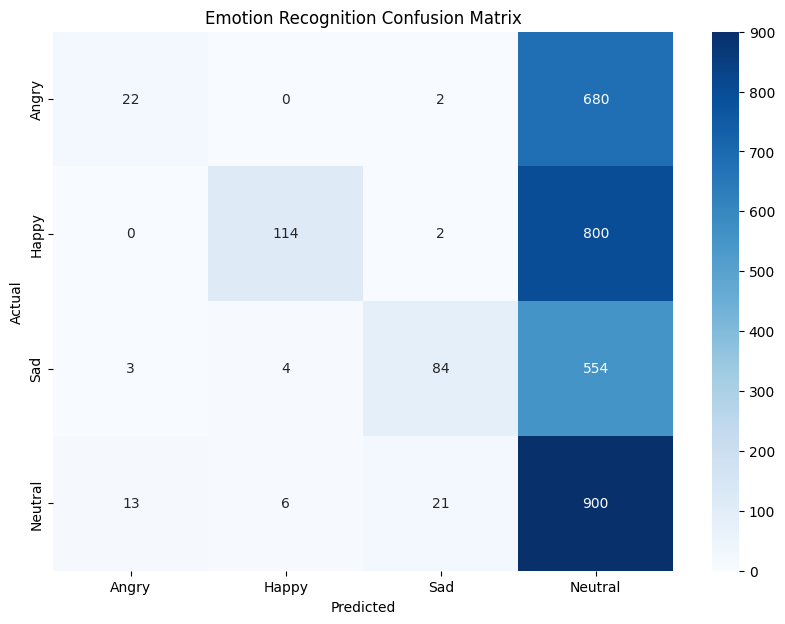

In [11]:
evaluate_results("../../../results/4way/iemocap_llm/results_gemini.csv")